In [2]:
import numpy as np
import pandas as pd

np.random.seed(23)

# Class 1
mu_vec1 = np.array([0, 0, 0])
cov_mat1 = np.array([[1,0,0],
                     [0,1,0],
                     [0,0,1]])

class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,
                  columns=['feature1','feature2','feature3'])

df['target'] = 1

# Class 2
mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],
                     [0,1,0],
                     [0,0,1]])

class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,
                   columns=['feature1','feature2','feature3'])

df1['target'] = 0

# Combine DataFrames
df = pd.concat([df, df1], ignore_index=True)

# Shuffle rows
df = df.sample(frac=1, random_state=23).reset_index(drop=True)

print(df.head())

   feature1  feature2  feature3  target
0 -0.331617 -1.632386  0.619114       1
1  1.010229  1.437830  2.327788       0
2  0.241106 -0.952510 -0.136267       1
3  1.676860  4.187503 -0.080565       0
4  2.823378 -0.332863  2.637391       0


In [3]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()
     

In [4]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [5]:
df.head()

,feature1,feature2,feature3,target
0,-0.669383,-1.998011,-0.042684,1
1,0.504227,0.932620,1.459332,0
2,-0.168466,-1.349045,-0.706704,1
3,1.087278,3.557281,-0.657739,0
4,2.090049,-0.757570,1.731490,0


In [6]:
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [7]:

# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [8]:

eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [9]:

eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

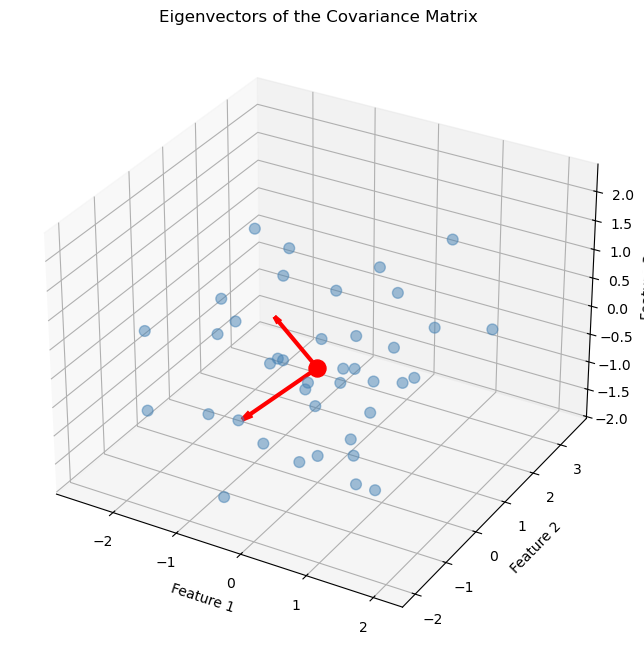

In [14]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ===========================
# Data Matrix
# ===========================

X = df[['feature1', 'feature2', 'feature3']].values

# Mean Centering
X = X - X.mean(axis=0)

# Covariance Matrix
cov_mat = np.cov(X.T)

# Eigen Decomposition
eigen_values, eigen_vectors = np.linalg.eig(cov_mat)

# ===========================
# Plot
# ===========================

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot Data Points
ax.scatter(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    color='steelblue',
    s=60,
    alpha=0.5
)

# Mean Point
mean = df[['feature1', 'feature2', 'feature3']].mean().values

ax.scatter(
    mean[0],
    mean[1],
    mean[2],
    color='red',
    s=150,
    label='Mean'
)

# ===========================
# Plot Eigenvectors
# (Scaled by eigenvalues)
# ===========================

for i in range(len(eigen_values)):
    v = eigen_vectors[:, i]

    ax.quiver(
        mean[0],
        mean[1],
        mean[2],
        v[0] * eigen_values[i],
        v[1] * eigen_values[i],
        v[2] * eigen_values[i],
        color='red',
        linewidth=3,
        arrow_length_ratio=0.12
    )

# ===========================
# Labels
# ===========================

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')

ax.set_title('Eigenvectors of the Covariance Matrix')

plt.show()

In [15]:
pc = eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [16]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,1.726114,0.492511,1
1,-0.220797,-1.441911,0
2,0.688605,0.658084,1
3,-3.367715,-0.254627,0
4,0.227326,-2.669841,0


In [17]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()